In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv(r"C:\Users\Surface Pro 7\Downloads\archive (3)\anime.csv")

In [10]:
print(df.dtypes)

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object


In [11]:
object_cols = df.select_dtypes(include=['object']).columns

In [12]:
object_cols

Index(['name', 'genre', 'type', 'episodes'], dtype='object')

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in object_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [14]:
df.dtypes

anime_id      int64
name          int64
genre         int64
type          int64
episodes      int64
rating      float64
members       int64
dtype: object

In [15]:
df = df.fillna(df.mean(numeric_only=True))

In [16]:
scaler = StandardScaler()

In [17]:
scaled_data = scaler.fit_transform(df)

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [19]:
df['Cluster'] = kmeans.fit_predict(scaled_data)

In [20]:
df

,anime_id,name,genre,type,episodes,rating,members,Cluster
0,32281,5412,2686,0,0,9.37,200630,2
1,5114,2848,161,5,147,9.26,793665,2
2,28977,3346,534,5,132,9.25,114262,2
3,9253,10259,3240,5,84,9.17,673572,2
4,9969,3337,534,5,132,9.16,151266,2
...,...,...,...,...,...,...,...,...
12289,9316,11144,2903,3,0,4.15,211,1
12290,5543,11418,2903,3,0,4.28,183,1
12291,5621,11562,2903,3,118,4.88,219,0
12292,6133,11563,2903,3,0,4.98,175,1


In [21]:
wcss = []

In [22]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

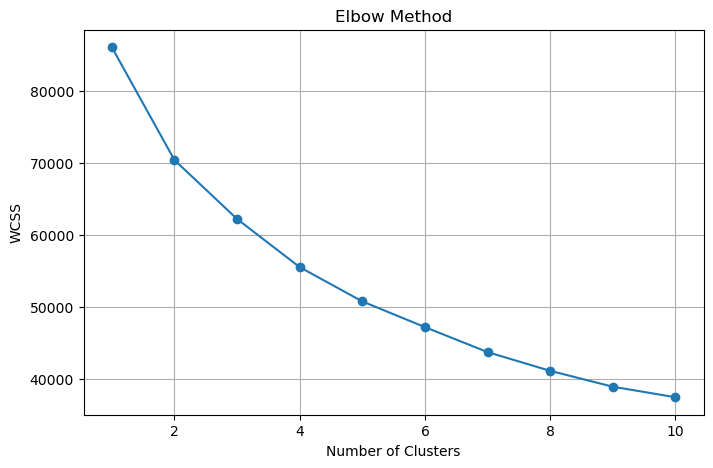

In [23]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [24]:
clusters = kmeans.fit_predict(scaled_data)

In [26]:
df['Cluster'] = clusters

In [28]:
df.head()

,anime_id,name,genre,type,episodes,rating,members,Cluster
0,32281,5412,2686,0,0,9.37,200630,4
1,5114,2848,161,5,147,9.26,793665,4
2,28977,3346,534,5,132,9.25,114262,6
3,9253,10259,3240,5,84,9.17,673572,4
4,9969,3337,534,5,132,9.16,151266,4


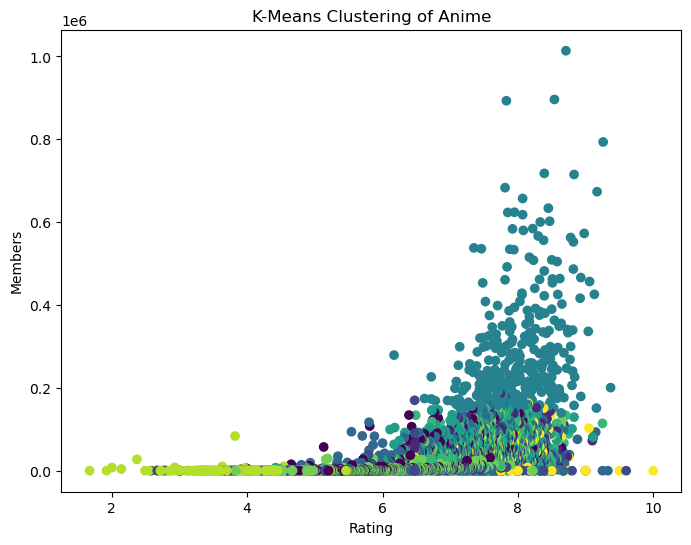

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(df['rating'],
            df['members'],
            c=df['Cluster'])

plt.xlabel("Rating")
plt.ylabel("Members")
plt.title("K-Means Clustering of Anime")
plt.show()

In [31]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

In [32]:
print("Cluster Centers")
print(centers)

Cluster Centers
[[7.04555810e+03 3.16543302e+03 2.50512317e+03 3.58603175e+00
  2.97060317e+01 6.39095238e+00 1.02931663e+04]
 [8.89746146e+03 3.08029854e+03 1.34088098e+03 3.89268293e-01
  8.27317073e-01 6.83295418e+00 1.44889171e+04]
 [2.82770488e+04 6.09457425e+03 2.09405088e+03 4.04880582e+00
  1.41737279e+02 6.08353963e+00 3.92912773e+03]
 [2.75246669e+04 6.05808588e+03 2.30167990e+03 3.75016265e+00
  1.40787248e+01 6.70811558e+00 1.33779375e+04]
 [1.18796136e+04 5.49764307e+03 1.48291445e+03 4.70206490e+00
  4.95044248e+01 8.00079646e+00 2.79495440e+05]
 [8.44971681e+03 8.57781892e+03 8.18419333e+02 4.17494894e+00
  4.12239619e+01 6.92756147e+00 2.16429489e+04]
 [4.83676491e+03 3.69989431e+03 1.42563144e+03 4.34349593e+00
  1.13849593e+02 6.92038618e+00 1.38302995e+04]
 [6.72747477e+03 9.64576132e+03 2.54652329e+03 3.80012937e+00
  6.90310479e+01 6.50932083e+00 8.31653040e+03]
 [2.58371355e+04 6.06870989e+03 2.50344908e+03 1.16923077e+00
  4.15677656e+00 4.80474939e+00 3.64900366

In [34]:
print(df['Cluster'].value_counts())

Cluster
0    1575
7    1545
3    1537
6    1476
5    1469
8    1363
1    1025
9    1002
2     963
4     339
Name: count, dtype: int64
